In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:98% !important;}
div.cell.code_cell.rendered{width:100%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:20pt;}
div.text_cell_render.rendered_html{font-size:18pt;}
div.text_cell_render.rendered_html{font-size:15pt;}
div.output {font-size:18pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:18pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:18pt;padding:5px;}
table.dataframe{font-size:18px;}
</style>
"""))

# 1. 기존의 프로그램 방식
-회귀분석(linear regression) 설명 사이트 : https://gbhat.com/machine_learning/linear_regression.html
-오차함수 : MSE(오차제곱평균), RMSE(루트를 취하기 때문에 MSE의 단점이 어느정도 해소. 이상치에 덜 민감), MAE(mean absolute erro error ; 절대값평균)
-
https://jysden.medium.com/%EC%96%B8%EC%A0%9C-mse-mae-rmse%EB%A5%BC-%EC%82%AC%EC%9A%A9%ED%95%98%EB%8A%94%EA%B0%80-c473bd831c62
![image](https://miro.medium.com/v2/resize:fit:720/format:webp/1*XRXgMqrr5rq-V1rW7SkrtA.png)
-경사하강법 설명
-https://www.mql5.com/ko/articles/11200

In [2]:
# 섭씨온도를 화씨온도를 출력
def celsius_to_faherenheit(c):
    return c * 1.8 + 32

In [3]:
input_c = int(input('섭씨온도 ?'))
print('화씨온도는', celsius_to_faherenheit(input_c))

섭씨온도 ?1
화씨온도는 33.8


# 2. 머신러닝 프로그램 방식
```
1. 데이터 확보 및 생성
2. 데이터 전처리 : 
    스케일 조정
    훈련데이터(학습데이터셋), 검증데이터셋, 시험데이터셋
3. 모델구성
4. 모델 학습과정 설정
5. 모델 학습시키기
6. 모델 평가(시험데이터셋으로)
7. 모델 저장 및 사용(입력값이 주어지면 예측값 받기)
```
## 2.1 노이즈가 없는 데이터로 실습

In [4]:
import numpy as np
import matplotlib.pyplot as plt

In [5]:
# 1. 데이터 생성
data_C = np.arange(100) # 0부터 99까지
data_C # 독립변수(입력변수)

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,
       51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67,
       68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84,
       85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99])

In [6]:
data_F = celsius_to_faherenheit(data_C)
data_F # 종속변수(타겟변수, 출력변수)

array([ 32. ,  33.8,  35.6,  37.4,  39.2,  41. ,  42.8,  44.6,  46.4,
        48.2,  50. ,  51.8,  53.6,  55.4,  57.2,  59. ,  60.8,  62.6,
        64.4,  66.2,  68. ,  69.8,  71.6,  73.4,  75.2,  77. ,  78.8,
        80.6,  82.4,  84.2,  86. ,  87.8,  89.6,  91.4,  93.2,  95. ,
        96.8,  98.6, 100.4, 102.2, 104. , 105.8, 107.6, 109.4, 111.2,
       113. , 114.8, 116.6, 118.4, 120.2, 122. , 123.8, 125.6, 127.4,
       129.2, 131. , 132.8, 134.6, 136.4, 138.2, 140. , 141.8, 143.6,
       145.4, 147.2, 149. , 150.8, 152.6, 154.4, 156.2, 158. , 159.8,
       161.6, 163.4, 165.2, 167. , 168.8, 170.6, 172.4, 174.2, 176. ,
       177.8, 179.6, 181.4, 183.2, 185. , 186.8, 188.6, 190.4, 192.2,
       194. , 195.8, 197.6, 199.4, 201.2, 203. , 204.8, 206.6, 208.4,
       210.2])

In [7]:
# 2. 데이터 전처리 : 컴퓨터에게 학습시키기 위해 스케일 조정
scaled_data_C = data_C / 100.0
scaled_data_F = data_F / 100.0
print('학습시 독립변수 :', scaled_data_C)
print('학습시 타겟변수 :', scaled_data_F)

학습시 독립변수 : [0.   0.01 0.02 0.03 0.04 0.05 0.06 0.07 0.08 0.09 0.1  0.11 0.12 0.13
 0.14 0.15 0.16 0.17 0.18 0.19 0.2  0.21 0.22 0.23 0.24 0.25 0.26 0.27
 0.28 0.29 0.3  0.31 0.32 0.33 0.34 0.35 0.36 0.37 0.38 0.39 0.4  0.41
 0.42 0.43 0.44 0.45 0.46 0.47 0.48 0.49 0.5  0.51 0.52 0.53 0.54 0.55
 0.56 0.57 0.58 0.59 0.6  0.61 0.62 0.63 0.64 0.65 0.66 0.67 0.68 0.69
 0.7  0.71 0.72 0.73 0.74 0.75 0.76 0.77 0.78 0.79 0.8  0.81 0.82 0.83
 0.84 0.85 0.86 0.87 0.88 0.89 0.9  0.91 0.92 0.93 0.94 0.95 0.96 0.97
 0.98 0.99]
학습시 타겟변수 : [0.32  0.338 0.356 0.374 0.392 0.41  0.428 0.446 0.464 0.482 0.5   0.518
 0.536 0.554 0.572 0.59  0.608 0.626 0.644 0.662 0.68  0.698 0.716 0.734
 0.752 0.77  0.788 0.806 0.824 0.842 0.86  0.878 0.896 0.914 0.932 0.95
 0.968 0.986 1.004 1.022 1.04  1.058 1.076 1.094 1.112 1.13  1.148 1.166
 1.184 1.202 1.22  1.238 1.256 1.274 1.292 1.31  1.328 1.346 1.364 1.382
 1.4   1.418 1.436 1.454 1.472 1.49  1.508 1.526 1.544 1.562 1.58  1.598
 1.616 1.634 1.652 1.67  1.688 1

In [8]:
# import os
# os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
import tensorflow as tf
print(tf.__version__)
tf.config.list_physical_devices('GPU')

2.10.0


[]

In [9]:
# 3. 모델 구성
from tensorflow.keras.models import Sequential # 모델생성
from tensorflow.keras.layers import Dense, Input # 입력값과 출력값으로 layer층 지정

model = Sequential()
# model.add(Input(shape=(1,) ))
# model.add(Dense(1))
model.add(Dense(units=1, # 타겟(종속) 변수의 갯수
                input_shape=(1,))) # 입력(독립) 변수의 shape

In [10]:
# 4. 모델 학습과정 설정
model.compile(loss="mse", # 손실함수 - 모델 학습 중 오차를 최소화하기 위해 사용
             optimizer="rmsprop", # 옵티마이저
             metrics=['mae']) # 평가지표
# mse : 오차 제곱의 평균
# mae : 오차 절대값의 평균(이상치 영향이 감소)
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 1)                 2         
                                                                 
Total params: 2
Trainable params: 2
Non-trainable params: 0
_________________________________________________________________


In [11]:
# 학습전 예측
model.predict(np.array([[0],
                      [0.01]])) # 섭씨온도 0, 1도는 화씨온도 몇도?

1/1 [==============================] - 0s 82ms/step


array([[ 0.        ],
       [-0.01201224]], dtype=float32)

In [12]:
# 학습전 모델 저장
model.save('model/before_learning.h5')

In [13]:
# 5. 모델 학습시키기 - 1번만 실행
hist = model.fit(scaled_data_C, # 입력변수(훈련데이터)
                scaled_data_F, # 타겟변수(훈련데이터)
                epochs=1000, # 학습횟수
                verbose=2) # 학습시 출력여부(0:학습내용출력x)

Epoch 1/1000
4/4 - 0s - loss: 3.9929 - mae: 1.8011 - 403ms/epoch - 101ms/step
Epoch 2/1000
4/4 - 0s - loss: 3.9478 - mae: 1.7896 - 8ms/epoch - 2ms/step
Epoch 3/1000
4/4 - 0s - loss: 3.9185 - mae: 1.7820 - 9ms/epoch - 2ms/step
Epoch 4/1000
4/4 - 0s - loss: 3.8900 - mae: 1.7746 - 6ms/epoch - 2ms/step
Epoch 5/1000
4/4 - 0s - loss: 3.8666 - mae: 1.7686 - 9ms/epoch - 2ms/step
Epoch 6/1000
4/4 - 0s - loss: 3.8407 - mae: 1.7620 - 6ms/epoch - 2ms/step
Epoch 7/1000
4/4 - 0s - loss: 3.8164 - mae: 1.7557 - 10ms/epoch - 2ms/step
Epoch 8/1000
4/4 - 0s - loss: 3.7933 - mae: 1.7497 - 8ms/epoch - 2ms/step
Epoch 9/1000
4/4 - 0s - loss: 3.7712 - mae: 1.7438 - 11ms/epoch - 3ms/step
Epoch 10/1000
4/4 - 0s - loss: 3.7497 - mae: 1.7382 - 6ms/epoch - 2ms/step
Epoch 11/1000
4/4 - 0s - loss: 3.7253 - mae: 1.7317 - 8ms/epoch - 2ms/step
Epoch 12/1000
4/4 - 0s - loss: 3.7052 - mae: 1.7264 - 10ms/epoch - 2ms/step
Epoch 13/1000
4/4 - 0s - loss: 3.6814 - mae: 1.7203 - 9ms/epoch - 2ms/step
Epoch 14/1000
4/4 - 0s - lo

Epoch 110/1000
4/4 - 0s - loss: 1.8910 - mae: 1.1639 - 7ms/epoch - 2ms/step
Epoch 111/1000
4/4 - 0s - loss: 1.8757 - mae: 1.1583 - 6ms/epoch - 2ms/step
Epoch 112/1000
4/4 - 0s - loss: 1.8602 - mae: 1.1526 - 7ms/epoch - 2ms/step
Epoch 113/1000
4/4 - 0s - loss: 1.8445 - mae: 1.1470 - 6ms/epoch - 1ms/step
Epoch 114/1000
4/4 - 0s - loss: 1.8287 - mae: 1.1413 - 7ms/epoch - 2ms/step
Epoch 115/1000
4/4 - 0s - loss: 1.8147 - mae: 1.1364 - 6ms/epoch - 1ms/step
Epoch 116/1000
4/4 - 0s - loss: 1.7997 - mae: 1.1308 - 7ms/epoch - 2ms/step
Epoch 117/1000
4/4 - 0s - loss: 1.7854 - mae: 1.1257 - 7ms/epoch - 2ms/step
Epoch 118/1000
4/4 - 0s - loss: 1.7712 - mae: 1.1205 - 7ms/epoch - 2ms/step
Epoch 119/1000
4/4 - 0s - loss: 1.7570 - mae: 1.1154 - 5ms/epoch - 1ms/step
Epoch 120/1000
4/4 - 0s - loss: 1.7410 - mae: 1.1094 - 6ms/epoch - 1ms/step
Epoch 121/1000
4/4 - 0s - loss: 1.7261 - mae: 1.1041 - 6ms/epoch - 1ms/step
Epoch 122/1000
4/4 - 0s - loss: 1.7136 - mae: 1.0995 - 6ms/epoch - 1ms/step
Epoch 123/10

Epoch 218/1000
4/4 - 0s - loss: 0.6830 - mae: 0.6763 - 8ms/epoch - 2ms/step
Epoch 219/1000
4/4 - 0s - loss: 0.6745 - mae: 0.6722 - 9ms/epoch - 2ms/step
Epoch 220/1000
4/4 - 0s - loss: 0.6688 - mae: 0.6697 - 8ms/epoch - 2ms/step
Epoch 221/1000
4/4 - 0s - loss: 0.6619 - mae: 0.6662 - 9ms/epoch - 2ms/step
Epoch 222/1000
4/4 - 0s - loss: 0.6540 - mae: 0.6626 - 6ms/epoch - 2ms/step
Epoch 223/1000
4/4 - 0s - loss: 0.6460 - mae: 0.6587 - 7ms/epoch - 2ms/step
Epoch 224/1000
4/4 - 0s - loss: 0.6392 - mae: 0.6554 - 9ms/epoch - 2ms/step
Epoch 225/1000
4/4 - 0s - loss: 0.6327 - mae: 0.6521 - 9ms/epoch - 2ms/step
Epoch 226/1000
4/4 - 0s - loss: 0.6248 - mae: 0.6485 - 7ms/epoch - 2ms/step
Epoch 227/1000
4/4 - 0s - loss: 0.6182 - mae: 0.6451 - 7ms/epoch - 2ms/step
Epoch 228/1000
4/4 - 0s - loss: 0.6116 - mae: 0.6420 - 8ms/epoch - 2ms/step
Epoch 229/1000
4/4 - 0s - loss: 0.6042 - mae: 0.6384 - 8ms/epoch - 2ms/step
Epoch 230/1000
4/4 - 0s - loss: 0.5978 - mae: 0.6352 - 6ms/epoch - 1ms/step
Epoch 231/10

Epoch 326/1000
4/4 - 0s - loss: 0.2615 - mae: 0.4426 - 6ms/epoch - 1ms/step
Epoch 327/1000
4/4 - 0s - loss: 0.2608 - mae: 0.4419 - 5ms/epoch - 1ms/step
Epoch 328/1000
4/4 - 0s - loss: 0.2596 - mae: 0.4410 - 7ms/epoch - 2ms/step
Epoch 329/1000
4/4 - 0s - loss: 0.2585 - mae: 0.4402 - 6ms/epoch - 1ms/step
Epoch 330/1000
4/4 - 0s - loss: 0.2576 - mae: 0.4395 - 5ms/epoch - 1ms/step
Epoch 331/1000
4/4 - 0s - loss: 0.2565 - mae: 0.4386 - 6ms/epoch - 1ms/step
Epoch 332/1000
4/4 - 0s - loss: 0.2553 - mae: 0.4376 - 7ms/epoch - 2ms/step
Epoch 333/1000
4/4 - 0s - loss: 0.2541 - mae: 0.4366 - 6ms/epoch - 2ms/step
Epoch 334/1000
4/4 - 0s - loss: 0.2533 - mae: 0.4359 - 6ms/epoch - 1ms/step
Epoch 335/1000
4/4 - 0s - loss: 0.2526 - mae: 0.4352 - 5ms/epoch - 1ms/step
Epoch 336/1000
4/4 - 0s - loss: 0.2518 - mae: 0.4346 - 8ms/epoch - 2ms/step
Epoch 337/1000
4/4 - 0s - loss: 0.2507 - mae: 0.4336 - 6ms/epoch - 1ms/step
Epoch 338/1000
4/4 - 0s - loss: 0.2492 - mae: 0.4323 - 6ms/epoch - 1ms/step
Epoch 339/10

Epoch 434/1000
4/4 - 0s - loss: 0.1659 - mae: 0.3520 - 7ms/epoch - 2ms/step
Epoch 435/1000
4/4 - 0s - loss: 0.1651 - mae: 0.3511 - 6ms/epoch - 1ms/step
Epoch 436/1000
4/4 - 0s - loss: 0.1644 - mae: 0.3503 - 7ms/epoch - 2ms/step
Epoch 437/1000
4/4 - 0s - loss: 0.1637 - mae: 0.3497 - 6ms/epoch - 1ms/step
Epoch 438/1000
4/4 - 0s - loss: 0.1631 - mae: 0.3490 - 7ms/epoch - 2ms/step
Epoch 439/1000
4/4 - 0s - loss: 0.1623 - mae: 0.3480 - 6ms/epoch - 1ms/step
Epoch 440/1000
4/4 - 0s - loss: 0.1616 - mae: 0.3474 - 5ms/epoch - 1ms/step
Epoch 441/1000
4/4 - 0s - loss: 0.1609 - mae: 0.3465 - 5ms/epoch - 1ms/step
Epoch 442/1000
4/4 - 0s - loss: 0.1600 - mae: 0.3456 - 7ms/epoch - 2ms/step
Epoch 443/1000
4/4 - 0s - loss: 0.1592 - mae: 0.3448 - 6ms/epoch - 1ms/step
Epoch 444/1000
4/4 - 0s - loss: 0.1584 - mae: 0.3438 - 7ms/epoch - 2ms/step
Epoch 445/1000
4/4 - 0s - loss: 0.1577 - mae: 0.3431 - 6ms/epoch - 1ms/step
Epoch 446/1000
4/4 - 0s - loss: 0.1570 - mae: 0.3424 - 6ms/epoch - 1ms/step
Epoch 447/10

Epoch 542/1000
4/4 - 0s - loss: 0.0928 - mae: 0.2629 - 6ms/epoch - 1ms/step
Epoch 543/1000
4/4 - 0s - loss: 0.0922 - mae: 0.2621 - 6ms/epoch - 1ms/step
Epoch 544/1000
4/4 - 0s - loss: 0.0917 - mae: 0.2614 - 7ms/epoch - 2ms/step
Epoch 545/1000
4/4 - 0s - loss: 0.0910 - mae: 0.2604 - 6ms/epoch - 1ms/step
Epoch 546/1000
4/4 - 0s - loss: 0.0903 - mae: 0.2595 - 7ms/epoch - 2ms/step
Epoch 547/1000
4/4 - 0s - loss: 0.0897 - mae: 0.2587 - 7ms/epoch - 2ms/step
Epoch 548/1000
4/4 - 0s - loss: 0.0891 - mae: 0.2577 - 7ms/epoch - 2ms/step
Epoch 549/1000
4/4 - 0s - loss: 0.0885 - mae: 0.2568 - 6ms/epoch - 1ms/step
Epoch 550/1000
4/4 - 0s - loss: 0.0878 - mae: 0.2559 - 6ms/epoch - 1ms/step
Epoch 551/1000
4/4 - 0s - loss: 0.0871 - mae: 0.2550 - 6ms/epoch - 1ms/step
Epoch 552/1000
4/4 - 0s - loss: 0.0866 - mae: 0.2542 - 7ms/epoch - 2ms/step
Epoch 553/1000
4/4 - 0s - loss: 0.0860 - mae: 0.2532 - 6ms/epoch - 1ms/step
Epoch 554/1000
4/4 - 0s - loss: 0.0856 - mae: 0.2526 - 6ms/epoch - 1ms/step
Epoch 555/10

Epoch 650/1000
4/4 - 0s - loss: 0.0407 - mae: 0.1742 - 10ms/epoch - 2ms/step
Epoch 651/1000
4/4 - 0s - loss: 0.0402 - mae: 0.1733 - 7ms/epoch - 2ms/step
Epoch 652/1000
4/4 - 0s - loss: 0.0398 - mae: 0.1722 - 6ms/epoch - 1ms/step
Epoch 653/1000
4/4 - 0s - loss: 0.0394 - mae: 0.1716 - 7ms/epoch - 2ms/step
Epoch 654/1000
4/4 - 0s - loss: 0.0391 - mae: 0.1710 - 7ms/epoch - 2ms/step
Epoch 655/1000
4/4 - 0s - loss: 0.0387 - mae: 0.1702 - 6ms/epoch - 1ms/step
Epoch 656/1000
4/4 - 0s - loss: 0.0384 - mae: 0.1695 - 7ms/epoch - 2ms/step
Epoch 657/1000
4/4 - 0s - loss: 0.0380 - mae: 0.1684 - 7ms/epoch - 2ms/step
Epoch 658/1000
4/4 - 0s - loss: 0.0377 - mae: 0.1678 - 5ms/epoch - 1ms/step
Epoch 659/1000
4/4 - 0s - loss: 0.0373 - mae: 0.1668 - 7ms/epoch - 2ms/step
Epoch 660/1000
4/4 - 0s - loss: 0.0370 - mae: 0.1662 - 6ms/epoch - 1ms/step
Epoch 661/1000
4/4 - 0s - loss: 0.0366 - mae: 0.1653 - 7ms/epoch - 2ms/step
Epoch 662/1000
4/4 - 0s - loss: 0.0363 - mae: 0.1644 - 6ms/epoch - 1ms/step
Epoch 663/1

Epoch 758/1000
4/4 - 0s - loss: 0.0100 - mae: 0.0864 - 6ms/epoch - 1ms/step
Epoch 759/1000
4/4 - 0s - loss: 0.0099 - mae: 0.0856 - 7ms/epoch - 2ms/step
Epoch 760/1000
4/4 - 0s - loss: 0.0097 - mae: 0.0850 - 7ms/epoch - 2ms/step
Epoch 761/1000
4/4 - 0s - loss: 0.0095 - mae: 0.0843 - 7ms/epoch - 2ms/step
Epoch 762/1000
4/4 - 0s - loss: 0.0094 - mae: 0.0835 - 7ms/epoch - 2ms/step
Epoch 763/1000
4/4 - 0s - loss: 0.0092 - mae: 0.0828 - 7ms/epoch - 2ms/step
Epoch 764/1000
4/4 - 0s - loss: 0.0090 - mae: 0.0819 - 6ms/epoch - 1ms/step
Epoch 765/1000
4/4 - 0s - loss: 0.0088 - mae: 0.0811 - 6ms/epoch - 1ms/step
Epoch 766/1000
4/4 - 0s - loss: 0.0086 - mae: 0.0801 - 6ms/epoch - 1ms/step
Epoch 767/1000
4/4 - 0s - loss: 0.0085 - mae: 0.0794 - 5ms/epoch - 1ms/step
Epoch 768/1000
4/4 - 0s - loss: 0.0083 - mae: 0.0785 - 5ms/epoch - 1ms/step
Epoch 769/1000
4/4 - 0s - loss: 0.0081 - mae: 0.0776 - 6ms/epoch - 1ms/step
Epoch 770/1000
4/4 - 0s - loss: 0.0079 - mae: 0.0766 - 6ms/epoch - 1ms/step
Epoch 771/10

4/4 - 0s - loss: 2.7524e-05 - mae: 0.0045 - 7ms/epoch - 2ms/step
Epoch 865/1000
4/4 - 0s - loss: 1.9939e-05 - mae: 0.0038 - 6ms/epoch - 1ms/step
Epoch 866/1000
4/4 - 0s - loss: 1.5998e-05 - mae: 0.0034 - 6ms/epoch - 1ms/step
Epoch 867/1000
4/4 - 0s - loss: 1.1763e-05 - mae: 0.0029 - 6ms/epoch - 2ms/step
Epoch 868/1000
4/4 - 0s - loss: 6.9726e-06 - mae: 0.0023 - 6ms/epoch - 1ms/step
Epoch 869/1000
4/4 - 0s - loss: 4.4875e-06 - mae: 0.0018 - 6ms/epoch - 1ms/step
Epoch 870/1000
4/4 - 0s - loss: 3.7025e-06 - mae: 0.0016 - 7ms/epoch - 2ms/step
Epoch 871/1000
4/4 - 0s - loss: 1.5880e-06 - mae: 0.0011 - 7ms/epoch - 2ms/step
Epoch 872/1000
4/4 - 0s - loss: 1.4284e-06 - mae: 0.0010 - 6ms/epoch - 1ms/step
Epoch 873/1000
4/4 - 0s - loss: 3.7053e-07 - mae: 5.1583e-04 - 6ms/epoch - 2ms/step
Epoch 874/1000
4/4 - 0s - loss: 5.1431e-07 - mae: 6.2720e-04 - 6ms/epoch - 1ms/step
Epoch 875/1000
4/4 - 0s - loss: 5.4962e-07 - mae: 7.0110e-04 - 6ms/epoch - 1ms/step
Epoch 876/1000
4/4 - 0s - loss: 4.5591e-07 

Epoch 963/1000
4/4 - 0s - loss: 4.8826e-08 - mae: 1.8328e-04 - 6ms/epoch - 1ms/step
Epoch 964/1000
4/4 - 0s - loss: 2.0819e-06 - mae: 0.0014 - 6ms/epoch - 1ms/step
Epoch 965/1000
4/4 - 0s - loss: 3.6499e-07 - mae: 5.7691e-04 - 7ms/epoch - 2ms/step
Epoch 966/1000
4/4 - 0s - loss: 1.0286e-07 - mae: 3.1496e-04 - 6ms/epoch - 1ms/step
Epoch 967/1000
4/4 - 0s - loss: 1.3235e-07 - mae: 3.4046e-04 - 6ms/epoch - 1ms/step
Epoch 968/1000
4/4 - 0s - loss: 8.2650e-07 - mae: 8.3338e-04 - 7ms/epoch - 2ms/step
Epoch 969/1000
4/4 - 0s - loss: 1.6125e-06 - mae: 0.0011 - 6ms/epoch - 1ms/step
Epoch 970/1000
4/4 - 0s - loss: 1.1228e-08 - mae: 9.2179e-05 - 6ms/epoch - 1ms/step
Epoch 971/1000
4/4 - 0s - loss: 4.3071e-09 - mae: 5.7554e-05 - 7ms/epoch - 2ms/step
Epoch 972/1000
4/4 - 0s - loss: 5.0982e-08 - mae: 2.0014e-04 - 5ms/epoch - 1ms/step
Epoch 973/1000
4/4 - 0s - loss: 1.7447e-06 - mae: 0.0013 - 6ms/epoch - 1ms/step
Epoch 974/1000
4/4 - 0s - loss: 2.2261e-07 - mae: 4.5512e-04 - 6ms/epoch - 1ms/step
Epoc

In [14]:
# 6. 모델 평가(그래프를 통해 loss와 metrics 값의 추이, 평가함수)
print(hist.history.keys())
print(hist.history['loss'][:5])
print(hist.history['mae'][:5])

dict_keys(['loss', 'mae'])
[3.9929091930389404, 3.9478180408477783, 3.9185476303100586, 3.889957904815674, 3.8666391372680664]
[1.8010705709457397, 1.7896075248718262, 1.782014012336731, 1.774640679359436, 1.7686206102371216]


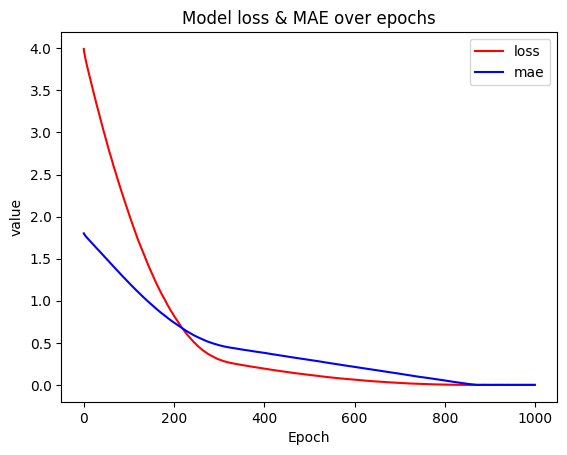

In [17]:
plt.plot(hist.history['loss'], 'r', label='loss')
plt.plot(hist.history['mae'], 'b', label='mae')
plt.legend() # 범례 label 추가
plt.xlabel('Epoch')
plt.ylabel('value')
plt.title('Model loss & MAE over epochs')
plt.show()

In [18]:
# 7. 모델 저장 및 사용
# 학습 후 예측
model.predict(np.array([[0],
                       [0.01]])) # 섭씨온도 0, 1도는 화씨온도 몇도?

1/1 [==============================] - 0s 22ms/step


array([[0.31936523],
       [0.3373615 ]], dtype=float32)

In [19]:
model.save('model/after_learning.h5')

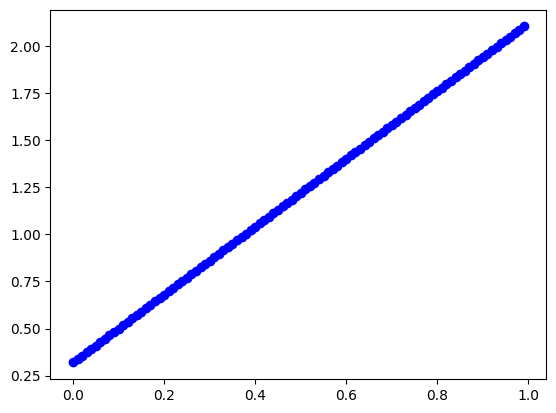

In [20]:
# 실제값
plt.scatter(x=scaled_data_C,
           y=scaled_data_F,
           c='b')
plt.show()

In [23]:
# 예측값
y_hat = model.predict([scaled_data_C])
for h, y in zip(y_hat, scaled_data_F):
    print('예측값:{}, 실제값:, 오차:{}'.format(h,
                                      y,
                                      h[0]-y))

4/4 [==============================] - 0s 2ms/step
예측값:[0.31936523], 실제값:, 오차:0.32
예측값:[0.3373615], 실제값:, 오차:0.33799999999999997
예측값:[0.35535777], 실제값:, 오차:0.35600000000000004
예측값:[0.37335405], 실제값:, 오차:0.374
예측값:[0.3913503], 실제값:, 오차:0.392
예측값:[0.40934658], 실제값:, 오차:0.41
예측값:[0.42734283], 실제값:, 오차:0.428
예측값:[0.4453391], 실제값:, 오차:0.446
예측값:[0.4633354], 실제값:, 오차:0.46399999999999997
예측값:[0.48133165], 실제값:, 오차:0.48200000000000004
예측값:[0.49932793], 실제값:, 오차:0.5
예측값:[0.5173242], 실제값:, 오차:0.518
예측값:[0.53532046], 실제값:, 오차:0.536
예측값:[0.5533167], 실제값:, 오차:0.554
예측값:[0.571313], 실제값:, 오차:0.5720000000000001
예측값:[0.5893093], 실제값:, 오차:0.59
예측값:[0.6073055], 실제값:, 오차:0.608
예측값:[0.62530184], 실제값:, 오차:0.626
예측값:[0.6432981], 실제값:, 오차:0.644
예측값:[0.66129434], 실제값:, 오차:0.662
예측값:[0.67929065], 실제값:, 오차:0.68
예측값:[0.69728684], 실제값:, 오차:0.6980000000000001
예측값:[0.71528316], 실제값:, 오차:0.716
예측값:[0.73327947], 실제값:, 오차:0.7340000000000001
예측값:[0.75127566], 실제값:, 오차:0.752
예측값:[0.76927197], 실제값:, 오차:0.77
예측값:[0.7872682

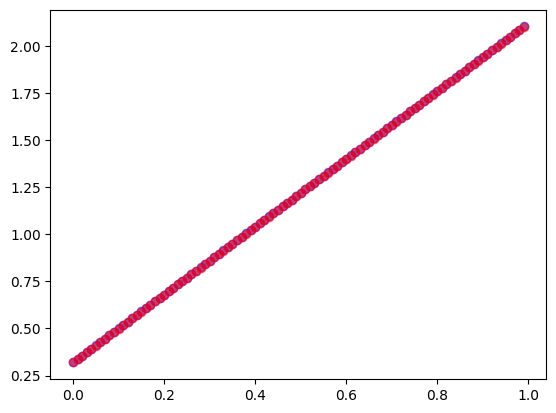

In [24]:
plt.scatter(x=scaled_data_C, y=scaled_data_F, c='b', alpha=0.5) # 투명한 점그래프
plt.scatter(x=scaled_data_C, y=y_hat, c='r', alpha=0.5)

## 2.2 노이즈가 있는 데이터로 실습

In [28]:
np.random.seed(7)
noise = np.random.normal(0, scale=0.1, size=100) # 평균0, 표준편차 0.1개 100개 데이터
noised_scaled_data_F = scaled_data_F + noise

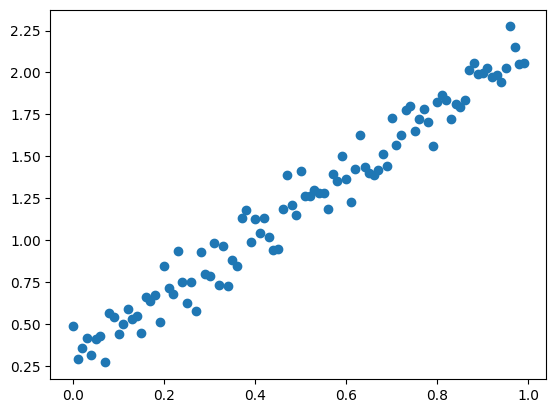

In [31]:
plt.scatter(x=scaled_data_C, y=noised_scaled_data_F)
plt.show()

In [32]:
# 3. 모델구성
model2 = Sequential()
model2.add(Dense(1, input_shape=(1,)))
# 4. 학습과정 설정
model2.compile(loss='mse', optimizer='rmsprop', metrics=['mae'])
model2.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_1 (Dense)             (None, 1)                 2         
                                                                 
Total params: 2
Trainable params: 2
Non-trainable params: 0
_________________________________________________________________


In [34]:
# 5. 모델 학습
hist2 = model2.fit(scaled_data_C, noised_scaled_data_F, epochs=1000, verbose=1)

Epoch 1/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.1355 - mae: 0.3523
Epoch 2/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.1276 - mae: 0.3414
Epoch 3/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.1219 - mae: 0.3331
Epoch 4/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.1170 - mae: 0.3257
Epoch 5/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.1129 - mae: 0.3195
Epoch 6/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.1090 - mae: 0.3135
Epoch 7/1000
4/4 [==============================] - 0s 3ms/step - loss: 0.1055 - mae: 0.3078
Epoch 8/1000
4/4 [==============================] - 0s 3ms/step - loss: 0.1021 - mae: 0.3023
Epoch 9/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0984 - mae: 0.2962
Epoch 10/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0951 - mae: 0.2906
Epoch 11/1000
4/4 [==============================] - 0s 2ms/step - lo

4/4 [==============================] - 0s 2ms/step - loss: 0.0109 - mae: 0.0842
Epoch 89/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0109 - mae: 0.0844
Epoch 90/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0109 - mae: 0.0840
Epoch 91/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0108 - mae: 0.0839
Epoch 92/1000
4/4 [==============================] - 0s 3ms/step - loss: 0.0108 - mae: 0.0838
Epoch 93/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0108 - mae: 0.0838
Epoch 94/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0108 - mae: 0.0838
Epoch 95/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0108 - mae: 0.0837
Epoch 96/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0108 - mae: 0.0836
Epoch 97/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0108 - mae: 0.0835
Epoch 98/1000
4/4 [==============================] - 0s 2ms/step - loss: 0

4/4 [==============================] - 0s 2ms/step - loss: 0.0103 - mae: 0.0810
Epoch 175/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0103 - mae: 0.0809
Epoch 176/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0103 - mae: 0.0810
Epoch 177/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0103 - mae: 0.0809
Epoch 178/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0103 - mae: 0.0810
Epoch 179/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0103 - mae: 0.0811
Epoch 180/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0103 - mae: 0.0812
Epoch 181/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0103 - mae: 0.0813
Epoch 182/1000
4/4 [==============================] - 0s 1ms/step - loss: 0.0103 - mae: 0.0813
Epoch 183/1000
4/4 [==============================] - 0s 1ms/step - loss: 0.0103 - mae: 0.0814
Epoch 184/1000
4/4 [==============================] - 0s 2ms/step

4/4 [==============================] - 0s 2ms/step - loss: 0.0103 - mae: 0.0809
Epoch 261/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0103 - mae: 0.0807
Epoch 262/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0103 - mae: 0.0808
Epoch 263/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0103 - mae: 0.0807
Epoch 264/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0103 - mae: 0.0808
Epoch 265/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0103 - mae: 0.0809
Epoch 266/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0103 - mae: 0.0806
Epoch 267/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0103 - mae: 0.0805
Epoch 268/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0103 - mae: 0.0806
Epoch 269/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0103 - mae: 0.0806
Epoch 270/1000
4/4 [==============================] - 0s 2ms/step

4/4 [==============================] - 0s 2ms/step - loss: 0.0103 - mae: 0.0806
Epoch 347/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0103 - mae: 0.0807
Epoch 348/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0103 - mae: 0.0808
Epoch 349/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0103 - mae: 0.0806
Epoch 350/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0103 - mae: 0.0808
Epoch 351/1000
4/4 [==============================] - 0s 3ms/step - loss: 0.0103 - mae: 0.0810
Epoch 352/1000
4/4 [==============================] - 0s 3ms/step - loss: 0.0103 - mae: 0.0809
Epoch 353/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0103 - mae: 0.0806
Epoch 354/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0103 - mae: 0.0807
Epoch 355/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0103 - mae: 0.0807
Epoch 356/1000
4/4 [==============================] - 0s 2ms/step

...

4/4 [==============================] - 0s 2ms/step - loss: 0.0103 - mae: 0.0805
Epoch 605/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0103 - mae: 0.0806
Epoch 606/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0103 - mae: 0.0808
Epoch 607/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0103 - mae: 0.0806
Epoch 608/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0103 - mae: 0.0809
Epoch 609/1000
4/4 [==============================] - 0s 3ms/step - loss: 0.0103 - mae: 0.0809
Epoch 610/1000
4/4 [==============================] - 0s 3ms/step - loss: 0.0103 - mae: 0.0807
Epoch 611/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0103 - mae: 0.0808
Epoch 612/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0103 - mae: 0.0809
Epoch 613/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0103 - mae: 0.0809
Epoch 614/1000
4/4 [==============================] - 0s 2ms/step

4/4 [==============================] - 0s 3ms/step - loss: 0.0103 - mae: 0.0808
Epoch 691/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0103 - mae: 0.0807
Epoch 692/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0103 - mae: 0.0811
Epoch 693/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0103 - mae: 0.0807
Epoch 694/1000
4/4 [==============================] - 0s 3ms/step - loss: 0.0103 - mae: 0.0808
Epoch 695/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0103 - mae: 0.0809
Epoch 696/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0103 - mae: 0.0806
Epoch 697/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0103 - mae: 0.0806
Epoch 698/1000
4/4 [==============================] - 0s 3ms/step - loss: 0.0103 - mae: 0.0806
Epoch 699/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0103 - mae: 0.0806
Epoch 700/1000
4/4 [==============================] - 0s 2ms/step

4/4 [==============================] - 0s 2ms/step - loss: 0.0103 - mae: 0.0807
Epoch 777/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0103 - mae: 0.0807
Epoch 778/1000
4/4 [==============================] - 0s 3ms/step - loss: 0.0103 - mae: 0.0806
Epoch 779/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0103 - mae: 0.0807
Epoch 780/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0103 - mae: 0.0806
Epoch 781/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0103 - mae: 0.0808
Epoch 782/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0103 - mae: 0.0806
Epoch 783/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0103 - mae: 0.0810
Epoch 784/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0103 - mae: 0.0806
Epoch 785/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0103 - mae: 0.0809
Epoch 786/1000
4/4 [==============================] - 0s 2ms/step

4/4 [==============================] - 0s 3ms/step - loss: 0.0103 - mae: 0.0807
Epoch 863/1000
4/4 [==============================] - 0s 3ms/step - loss: 0.0103 - mae: 0.0808
Epoch 864/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0103 - mae: 0.0809
Epoch 865/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0103 - mae: 0.0807
Epoch 866/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0103 - mae: 0.0806
Epoch 867/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0103 - mae: 0.0808
Epoch 868/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0103 - mae: 0.0808
Epoch 869/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0103 - mae: 0.0808
Epoch 870/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0103 - mae: 0.0806
Epoch 871/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0103 - mae: 0.0808
Epoch 872/1000
4/4 [==============================] - 0s 2ms/step

4/4 [==============================] - 0s 2ms/step - loss: 0.0103 - mae: 0.0805
Epoch 949/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0103 - mae: 0.0806
Epoch 950/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0103 - mae: 0.0808
Epoch 951/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0103 - mae: 0.0807
Epoch 952/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0103 - mae: 0.0806
Epoch 953/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0103 - mae: 0.0807
Epoch 954/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0103 - mae: 0.0808
Epoch 955/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0103 - mae: 0.0807
Epoch 956/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0103 - mae: 0.0806
Epoch 957/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0103 - mae: 0.0807
Epoch 958/1000
4/4 [==============================] - 0s 2ms/step

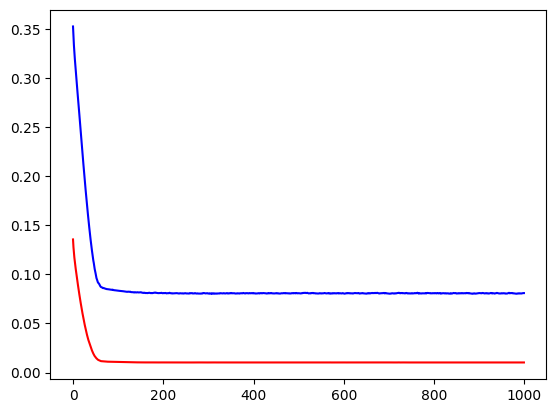

In [36]:
# 6.학습된 모델 과정 살펴보기
plt.plot(hist2.history['loss'], c='r')
plt.plot(hist2.history['mae'], c='b')

In [41]:
model2.save('model/noise_after_learning.h5')

In [38]:
# 예측값
y_hat = model2.predict([scaled_data_C])

4/4 [==============================] - 0s 1ms/step


In [39]:
for h, y in zip(y_hat, noised_scaled_data_F):
    print("실제값:{}, 예측값:{}, 오차:{}".format(y,
                                        h,
                                        h[0]-y))

실제값:0.48905257038003563, 예측값:[0.30477887], 오차:-0.18427369645959496
실제값:0.2914062629459167, 예측값:[0.32320398], 오차:0.03179771797678227
실제값:0.3592820163678585, 예측값:[0.34162906], 오차:-0.017652958245223616
실제값:0.4147516282996508, 예측값:[0.36005417], 오차:-0.0546974631747576
실제값:0.31310769713742614, 예측값:[0.37847924], 오차:0.06537154518740296
실제값:0.4102065572905948, 예측값:[0.39690435], 오차:-0.013302207963507395
실제값:0.42791096141420687, 예측값:[0.41532946], 오차:-0.012581505084861166
실제값:0.2705275693654579, 예측값:[0.43375453], 오차:0.1632269641638237
실제값:0.5657658005663493, 예측값:[0.4521796], 오차:-0.11358618983713176
실제값:0.542049851591955, 예측값:[0.47060472], 오차:-0.07144513386047913
실제값:0.43745710260332404, 예측값:[0.48902982], 오차:0.05157272213041009
실제값:0.5008451738804279, 예측값:[0.50745493], 오차:0.006609757855564502
실제값:0.5865299374196752, 예측값:[0.52588], 오차:-0.06064995828606923
실제값:0.5278643584808353, 예측값:[0.5443051], 오차:0.01644072765502891
실제값:0.5477250921327455, 예측값:[0.5627302], 오차:0.015005101005377108
실제값:0.44467585875

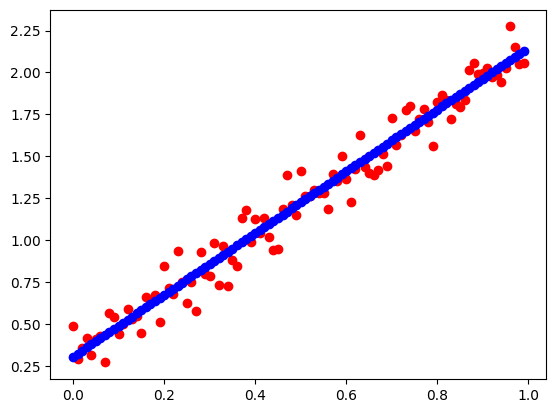

In [40]:
plt.scatter(x=scaled_data_C,
           y=noised_scaled_data_F,
           c='r')
plt.scatter(x=scaled_data_C,
           y=y_hat,
           c='b')